In [190]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("aslak")
import pandas as pd
from density_core import DensityCore
from grinsted_firn_model import *

S51 = DensityCore.load("_prepared_data/S5-1hxct_density_core.pkl")
S52 = DensityCore.load("_prepared_data/S5-2adj_density_core.pkl")
EG = DensityCore.load("_prepared_data/EGRIP_density_core.pkl")

# cores = [S51, S52, EG]
cores = [S51, EG]

In [ ]:
def multicore_fit(cores, rho=np.arange(350, 910, 5.0), min_a=0.01, max_a=1e6):
    # Takes a list of DensityCore's and tries makes the best fit a and b.
    # Assuming steady state.

    # allocate space for a(rho) and b(rho)
    a = np.full_like(rho, np.nan)
    b = np.full_like(rho, np.nan)

    # make a vectorized version of the gagliardni_ezz function
    gagli_vec = np.vectorize(gagliardini_ezz)

    # we can use a sigmoid transform to enforce limits on parameter search.
    sigmoid = lambda x: 1 / (1 + np.exp(-x))
    inverse_sigmoid = lambda y: np.log(y / (1 - y))

    N_cores = len(cores)
    for ix in range(len(rho)):
        this_rho = rho[ix]
        # --------------- Prepare data for fitting ------------
        # for every site we need vectors of e1,e2,sigma_zz,e_zz,T
        e1 = np.full(N_cores, np.nan)
        e2 = np.full(N_cores, np.nan)
        sigma_zz = np.full(N_cores, np.nan)
        T = np.full(N_cores, np.nan)
        e_zz = np.full(N_cores, np.nan)
        for cix, core in enumerate(cores):
            e1[cix] = core.e1 / sec_per_year
            e2[cix] = core.e2 / sec_per_year
            T[cix] = core.T
            overburden = np.interp(this_rho, core.rho, core.overburden)
            sigma_zz[cix] = -g * overburden
            drho_dz = np.interp(this_rho, core.rho, core.drho_dz)
            w = (core.bdot - overburden * (core.e1 + core.e2)) / this_rho
            e_zz[cix] = -w * drho_dz / this_rho - core.e1 - core.e2
            z = np.interp(this_rho, core.rho, core.z)

        # now we have all we need for fitting.

        if np.min(z) < 1:  # dont attempt using the model without any load.
            # near surface has no load and are affected by seasonal temperatures.
            continue

        if np.any(np.isnan(overburden)):
            # TODO: dont skip if we have more than 2 cores.
            continue

        # transform the parameter space so that it is impossible to exceed theoretical limits.
        x2a = lambda x: sigmoid(x[0]) * (max_a - min_a) + min_a  # a>=min_a
        # x2b = lambda x: x2a(x) * sigmoid(x[1]) * 9 / 2  # b<=9a/2 NICHOLAS
        # x2b = lambda x: x2a(x) * sigmoid(x[1]) * 3 / 2  # poisson>0
        # x2nu = lambda x: sigmoid(x[1]) * 0.5
        x2nu = lambda x: x[1]
        # x2b = lambda x: x2a(x) * (3 - 6 * x2nu(x)) / (2 * x2nu(x) + 2)
        x2b = lambda x: poisson_to_b(x2nu(x), x2a(x))

        a0 = a_fun(this_rho) / 5
        nu0 = poisson_from_ab(a_fun(this_rho), b_fun(this_rho))
        x00 = inverse_sigmoid((a0 - min_a) / (max_a - min_a))

        # using least squares:
        # deviance = lambda x: gagli_vec(sigma_zz, x2a([x,0.25]), x2b([x,0.25]), A_fun(273.15 + T), e1=e1, e2=e2) * sec_per_year - e_zz
        # res = least_squares(deviance, x0=[x00, -1])  # , method="lm")  # the LM method works very reliably
        # x01 = res.x[0]
        deviance = lambda x: gagli_vec(sigma_zz, x2a(x), x2b(x), A_fun(273.15 + T), e1=e1, e2=e2) * sec_per_year - e_zz
        res = least_squares(
            deviance, x0=[x00, nu0], bounds=[(-np.inf, 0), (np.inf, 0.5)], tr_solver="exact", gtol=1e-15
        )  # the LM method works very reliably

        if res.success:
            x = res.x
            a[ix], b[ix] = x2a(x), x2b(x)
        # display(res)
    return rho, a, b

In [192]:
rho, a, b = multicore_fit(cores, min_a=0.00001)

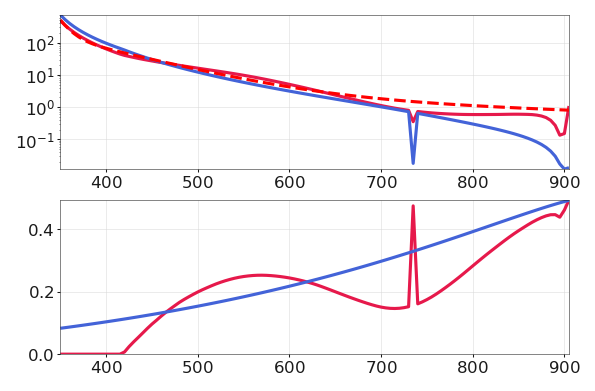

In [ ]:
plt.subplot(2, 1, 1)
plt.semilogy(rho, a)
plt.semilogy(rho, b)


def new_afun(rho, a_min=0.1, a600=18.05, slope600=-15.78652 / 921, a300=180, slope300=-0.04):
    # params:
    rhat = rho / 921
    duvacrow = (1 + (2 / 3) * (1 - rhat)) * (rhat ** (-1.5))
    return a_min * duvacrow + a600 * np.exp(slope600 * (rho - 600)) * 1 + a300 * np.exp(slope300 * (rho - 300))


plt.plot(rho, new_afun(rho, 7.64450290e-01, 2.45370533e00, -1.60778514e-02, 5.83517792e04, -1.01567484e-01), "r--")


# rho, a, b = multicore_fit(cores=[S51, S52], min_a=0.01)
# plt.semilogy(rho, a)
# plt.semilogy(rho, b)
# plt.semilogy(rho, a_fun(rho))
plt.subplot(2, 1, 2)
plt.plot(rho, poisson_from_ab(a, b))
plt.plot(rho, sigmoidal_poisson(rho, 643, 1.21))

In [194]:
output = {"rho": rho, "a": a, "b": b, "poisson": poisson_from_ab(a, b)}
df = pd.DataFrame(output)

In [195]:
df.to_parquet("_output/steadystate_fit.parquet", index=False)

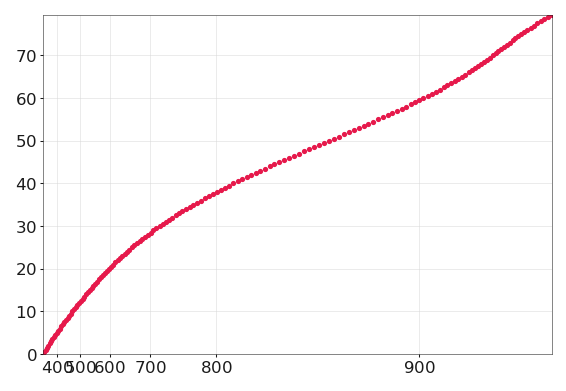

In [196]:
core = cores[0]
plt.plot(core.rho, core.z, ".")

t = 917
symlog = lambda x, thres: np.sign(x) * (np.log(1 + np.abs(x) / thres))
symexp = lambda y, thres: np.sign(y) * thres * (np.exp(y) - 1)
forward_transform = lambda rho: -symlog(t - rho, 1.0)
inverse_transform = lambda x: t - symexp(-x, 1.0)
plt.xscale("function", functions=(forward_transform, inverse_transform))